In [219]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll, make_moons

In [220]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataset

In [221]:
def get_swiss_roll(n_samples=5000):
    # Generate 3D swiss roll, but we only extract 2 dimensions to make it a 2D spiral
    data, _ = make_swiss_roll(n_samples=n_samples, noise=0.2)
    data = data[:, [0, 2]]
    # Standardize data to have zero mean and reasonable variance
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

In [222]:
def get_two_moons(n_samples=5000):
    data, _ = make_moons(n_samples=n_samples, noise=0.05)
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

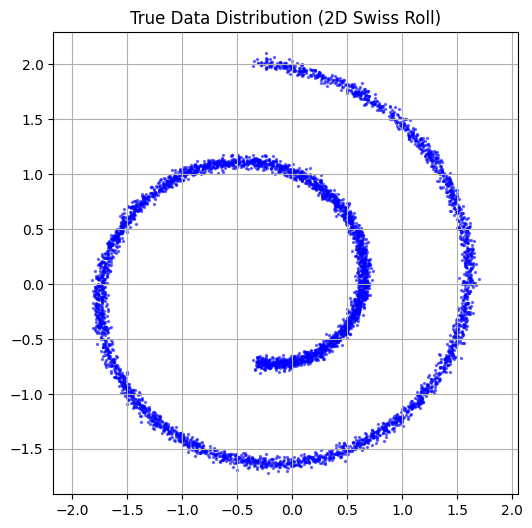

In [345]:
dataset = get_swiss_roll(5000)
# dataset = get_two_moons(5000)


plt.figure(figsize=(6, 6))
plt.scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
plt.title("True Data Distribution (2D Swiss Roll)")
plt.axis('equal')
plt.grid(True)
plt.show()

### Score Network

In [346]:
class ScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        # Input is 3-dimensional: 2D coordinate + 1D scalar sigma
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Softplus(), # Softplus ensures smooth second derivatives for score matching
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 2) # Output is a 2D vector (the score)
        )
        
    def forward(self, x, sigma):
        # x shape: [batch_size, 2]
        # sigma shape: [batch_size, 1]
        inputs = torch.cat([x, sigma], dim=-1)
        return self.net(inputs)

### L = noise Levels

In [450]:
L = 30                 # Number of noise scales
sigma_1 = 1.0           # High noise (blankets the empty canvas space)
sigma_L = 0.01          # Low noise (resolves fine structure)

In [451]:
# Calculate geometric progression base gamma
def make_schedule(sigma_1, sigma_L, L):
    gamma = (sigma_L / sigma_1) ** (1.0 / (L - 1))
    return torch.tensor([sigma_1 * (gamma ** i) for i in range(L)], dtype=torch.float32)

In [452]:
sigmas = make_schedule(sigma_1, sigma_L, L)

In [453]:
print("Noise Schedule (sigmas):")
for idx, s in enumerate(sigmas):
    print(f"Level {idx+1}: {s.item():.4f}")

Noise Schedule (sigmas):
Level 1: 1.0000
Level 2: 0.8532
Level 3: 0.7279
Level 4: 0.6210
Level 5: 0.5298
Level 6: 0.4520
Level 7: 0.3857
Level 8: 0.3290
Level 9: 0.2807
Level 10: 0.2395
Level 11: 0.2043
Level 12: 0.1743
Level 13: 0.1487
Level 14: 0.1269
Level 15: 0.1083
Level 16: 0.0924
Level 17: 0.0788
Level 18: 0.0672
Level 19: 0.0574
Level 20: 0.0489
Level 21: 0.0418
Level 22: 0.0356
Level 23: 0.0304
Level 24: 0.0259
Level 25: 0.0221
Level 26: 0.0189
Level 27: 0.0161
Level 28: 0.0137
Level 29: 0.0117
Level 30: 0.0100


### Training loop

In [455]:
def train_network(sigmas):

    network = ScoreNetwork(hidden_dim=128)
    optimizer = optim.Adam(network.parameters(), lr=0.001)
    epochs = 30000
    batch_size = 128

    for epoch in range(epochs):
    # 1. Sample a clean batch of data
        idx = torch.randint(0, len(dataset), (batch_size,))
        x_clean = dataset[idx]
        
        # 2. Randomly sample an index for the noise schedule per batch item
        noise_idx = torch.randint(0, L, (batch_size,))
        sigma = sigmas[noise_idx].unsqueeze(-1) # Shape: [batch_size, 1]
        
        # 3. Sample pure Gaussian noise
        z = torch.randn_like(x_clean)
        
        # 4. Create the perturbed noisy data
        x_noisy = x_clean + sigma * z
        
        # 5. Compute true analytical score target: -z / sigma
        target_score = -z / sigma
        
        # 6. Forward pass through network
        predicted_score = network(x_noisy, sigma)
        
        # 7. Weighted MSE Loss (scaled by sigma^2 to prevent high noise from drowning out low noise)
        loss = 0.5 * torch.mean(sigma**2 * torch.sum((predicted_score - target_score) ** 2, dim=-1))
        
        # Optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 400 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f}")
    
    return network

In [456]:
network = train_network(sigmas)

Epoch [400/30000] | Loss: 92.6216
Epoch [800/30000] | Loss: 189.4885
Epoch [1200/30000] | Loss: 161.8391
Epoch [1600/30000] | Loss: 151.3730
Epoch [2000/30000] | Loss: 144.6370
Epoch [2400/30000] | Loss: 154.3827
Epoch [2800/30000] | Loss: 230.3659
Epoch [3200/30000] | Loss: 175.3601
Epoch [3600/30000] | Loss: 83.4264
Epoch [4000/30000] | Loss: 182.9272
Epoch [4400/30000] | Loss: 154.3538
Epoch [4800/30000] | Loss: 170.4219
Epoch [5200/30000] | Loss: 198.3338
Epoch [5600/30000] | Loss: 140.1368
Epoch [6000/30000] | Loss: 106.3468
Epoch [6400/30000] | Loss: 246.7754
Epoch [6800/30000] | Loss: 161.8371
Epoch [7200/30000] | Loss: 126.9247
Epoch [7600/30000] | Loss: 120.0987
Epoch [8000/30000] | Loss: 140.0323
Epoch [8400/30000] | Loss: 207.2874
Epoch [8800/30000] | Loss: 85.8115
Epoch [9200/30000] | Loss: 138.0298
Epoch [9600/30000] | Loss: 172.4734
Epoch [10000/30000] | Loss: 105.9107
Epoch [10400/30000] | Loss: 208.8362
Epoch [10800/30000] | Loss: 146.1219
Epoch [11200/30000] | Loss: 20

### Sample using Annealed Langevin

In [457]:
def sample_annealed_langevin(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    with torch.no_grad():
        # Start from a broad Gaussian distribution matching our highest noise scale
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        # Outer Loop: Walk down through the noise levels from highest to lowest
        for i, sigma in enumerate(sigmas):
            # Compute step size dynamically scaled for this level
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            # Inner Loop: Run Langevin Dynamics for T steps at this noise level
            for t in range(T):
                # 1. Get the score vector field from our network
                score = network(x, sigma_tensor)
                
                # 2. Add fresh noise for the random shake
                z = torch.randn_like(x)
                
                # 3. Update equation
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
    return x.numpy()

### Samples

In [ ]:
generated_samples = sample_annealed_langevin(network, sigmas, n_samples=3000, T=100)

In [458]:
def plot_samples(dataset, generated_samples, title, plot_true=True):
    # 1. Dynamically set the number of columns based on plot_true
    n_cols = 2 if plot_true else 1
    
    # Adjust the overall figure width depending on the number of plots
    fig_width = 12 if plot_true else 6
    fig, axes = plt.subplots(1, n_cols, figsize=(fig_width, 6))

    # 2. If n_cols == 1, Matplotlib returns a single Axis object instead of a list/array.
    # To keep our indexing code uniform, we wrap it in a list if it isn't one.
    if n_cols == 1:
        axes = [axes]

    axis_idx = 0

    # 3. Plot True Data (only if requested)
    if plot_true:
        axes[axis_idx].scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
        axes[axis_idx].set_title("True Training Data")
        axes[axis_idx].set_xlim(-2.5, 2.5)
        axes[axis_idx].set_ylim(-2.5, 2.5)
        axes[axis_idx].grid(True)
        axis_idx += 1  # Move to the next plot slot

    # 4. Plot Generated Data
    axes[axis_idx].scatter(generated_samples[:, 0], generated_samples[:, 1], s=2, alpha=0.5, color='#a1112a')
    axes[axis_idx].set_title(title)
    axes[axis_idx].set_xlim(-2.5, 2.5)
    axes[axis_idx].set_ylim(-2.5, 2.5)
    axes[axis_idx].grid(True)

    plt.tight_layout() # Ensures labels don't overlap boundaries nicely
    plt.show()
    

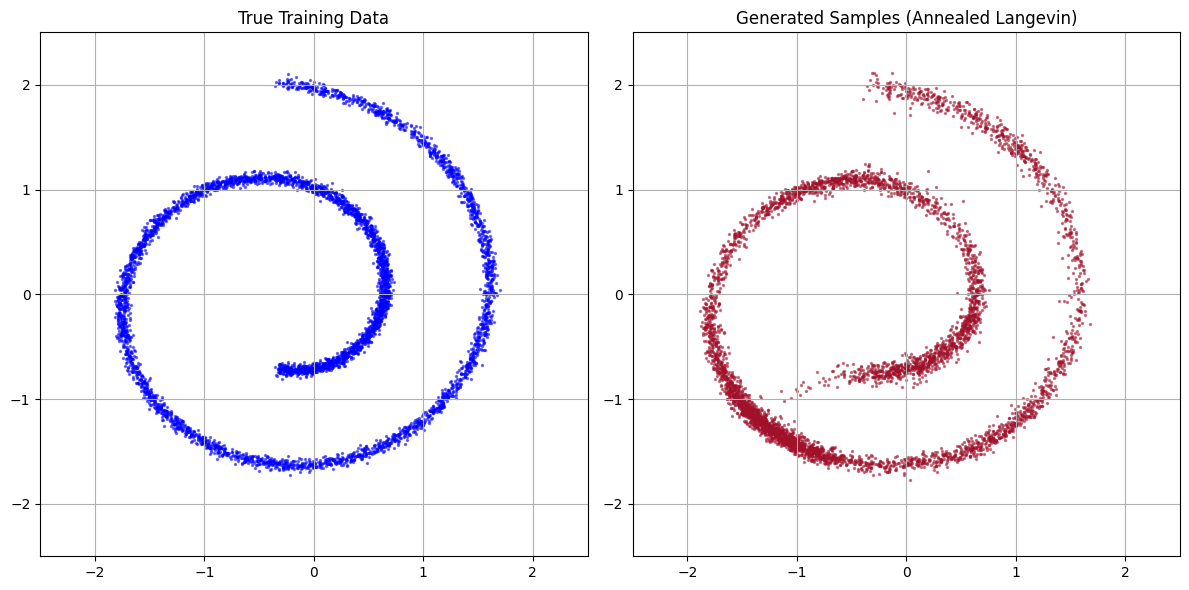

In [459]:
plot_samples(dataset, generated_samples, "Generated Samples (Annealed Langevin)", True)

### varying T, fixed L

In [460]:
samples_T_2  = sample_annealed_langevin(network, sigmas, n_samples=3000, T=2)
samples_T_50 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=50)
samples_T_100 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=100)
samples_T_200 = sample_annealed_langevin(network, sigmas, n_samples=3000, T=200)

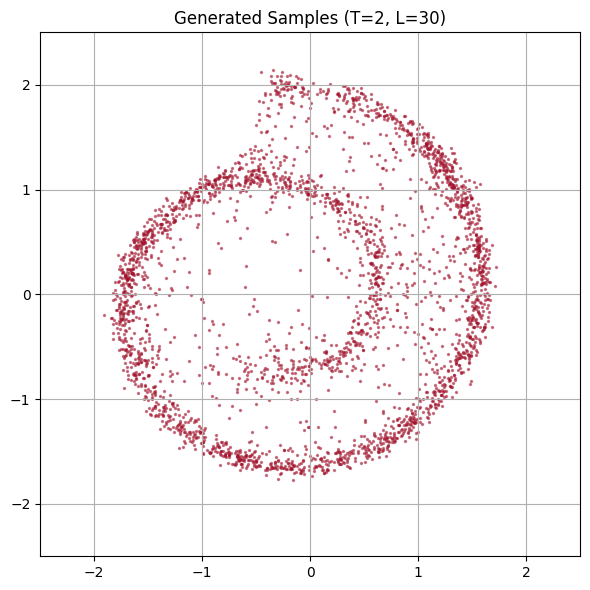

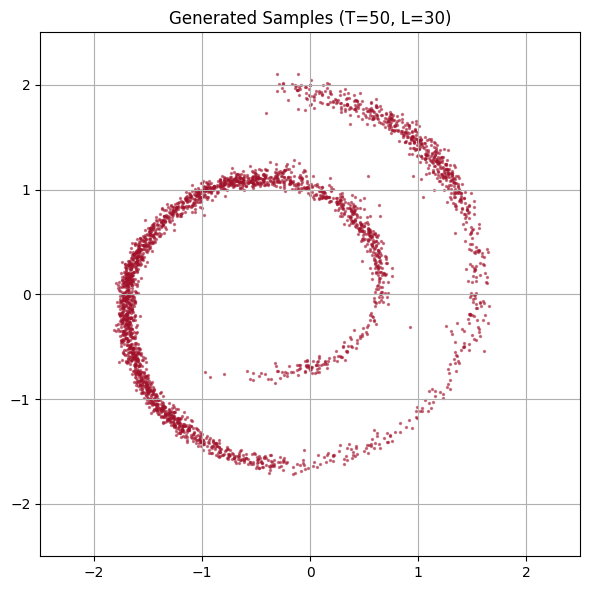

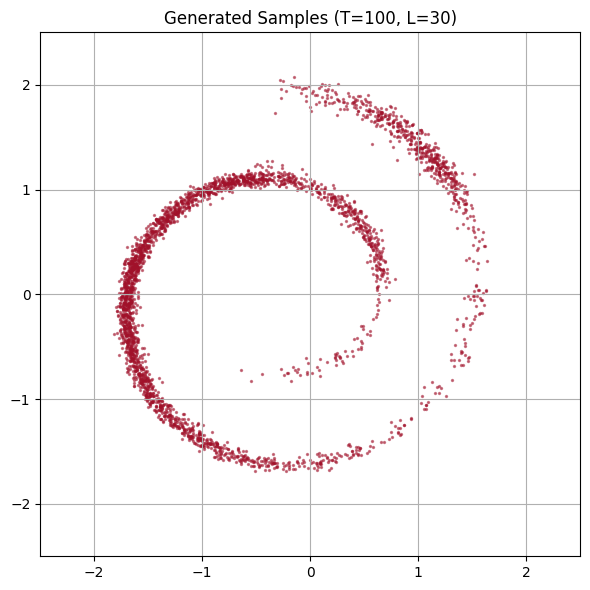

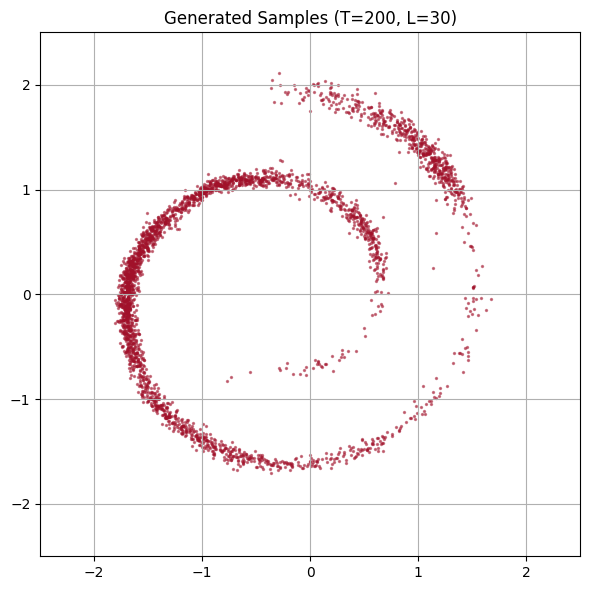

In [461]:
plot_samples(dataset, samples_T_2, "Generated Samples (T=2, L=30)", False)
plot_samples(dataset, samples_T_50, "Generated Samples (T=50, L=30)", False)
plot_samples(dataset, samples_T_100, "Generated Samples (T=100, L=30)", False)
plot_samples(dataset, samples_T_200, "Generated Samples (T=200, L=30)", False)

### varying L fixed T

In [462]:
L_SWEEP    = [10, 20, 30, 40, 50]
all_samples = {}
SIGMA_1 = 1.0
SIGMA_L = 0.01
BASELINE_EPS = 0.00002;
for L in L_SWEEP:
    sched          = make_schedule(SIGMA_1, SIGMA_L, L)
    adjusted_eps = BASELINE_EPS * (10 / L)
    samples        = sample_annealed_langevin(network, sched, 3000, T=30, eps=adjusted_eps)
    all_samples[L] = samples
    valid = int(np.isfinite(samples).all(axis=1).sum())
    # print(f"L={L:<3}  T={100}")

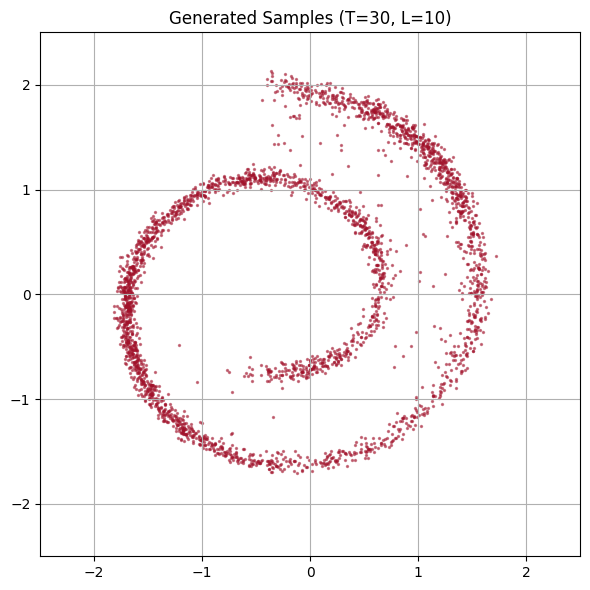

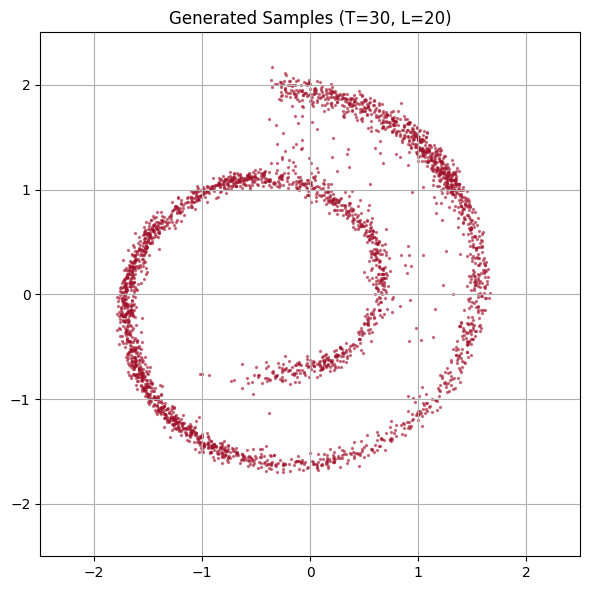

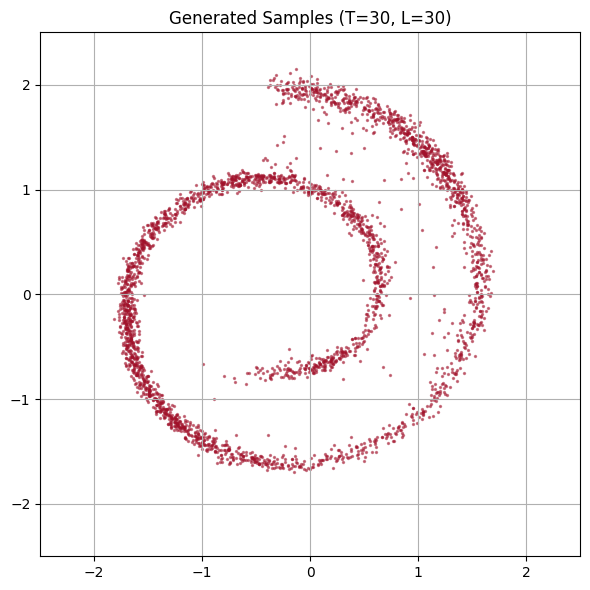

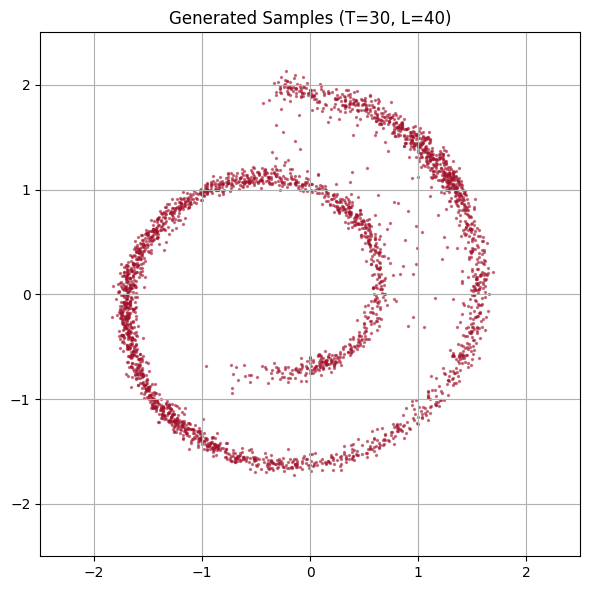

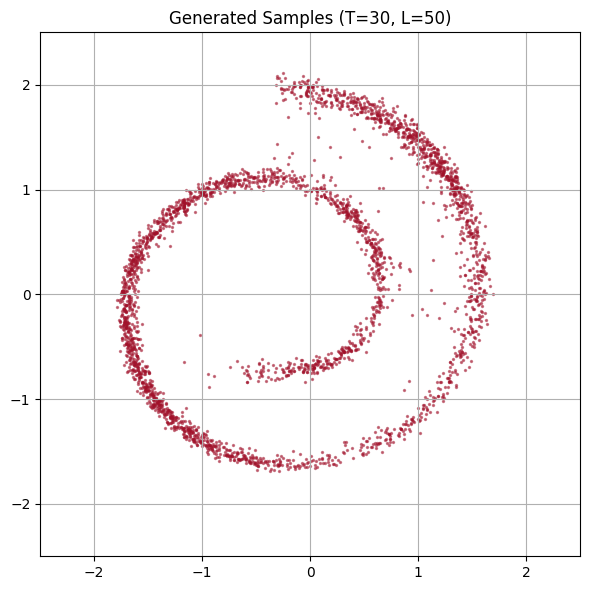

In [464]:
L_SWEEP    = [10, 20, 30, 40, 50]
for L in L_SWEEP:
    plot_samples(dataset, all_samples[L], f"Generated Samples (T=30, L={L})", False)

### score field plot

In [429]:
def plot_score_field_grid(network, sigmas, dataset, level_idx=4, grid_res=25):
    """
    Plots the score vector field at a specific noise level index.
    - level_idx: choose which index of the sigmas array to visualize (e.g., 0 to L-1)
    - grid_res: controls how dense the grid of arrows is (20 to 30 is ideal)
    """
    network.eval()
    sigma_val = sigmas[level_idx].item()
    
    # 1. Create a uniform 2D grid covering your data range
    x_range = np.linspace(-2.5, 2.5, grid_res)
    y_range = np.linspace(-2.5, 2.5, grid_res)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Flatten the grid coordinates to feed into PyTorch
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    # 2. Create the scalar sigma tensor matching the batch size of the grid
    sigma_tensor = torch.full((grid_tensor.shape[0], 1), sigma_val)
    
    # 3. Predict the score arrows
    with torch.no_grad():
        # Shape: [grid_res * grid_res, 2]
        predicted_scores = network(grid_tensor, sigma_tensor).numpy()
        
    # Reshape vectors back into a 2D grid structure for plotting
    U = predicted_scores[:, 0].reshape(X.shape)
    V = predicted_scores[:, 1].reshape(Y.shape)
    
    
    # 4. Compute magnitudes to visually color-code strong vs weak forces
    magnitudes = np.sqrt(U**2 + V**2)
    
    # 5. Plotting
    plt.figure(figsize=(6, 6))
    
    # Underlay a subset of the true data points for reference
    plt.scatter(dataset[:1000, 0], dataset[:1000, 1], s=4, color='blue', alpha=0.3, label='True Manifold')
    
    # Draw the vector arrows
    # angles='xy', scale_units='xy' ensure arrows scale accurately with the axis units
    quiver = plt.quiver(X, Y, U/magnitudes, V/magnitudes, magnitudes, cmap='inferno', 
                        angles='xy', scale_units='xy', scale=10, alpha=0.8)
    
    plt.colorbar(quiver, label='Score Vector Magnitude')
    plt.title(f"Learned Vector Score Field\nNoise Level {level_idx + 1}/{len(sigmas)} ($\\sigma$ = {sigma_val:.4f})")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.xlim(-2.7, 2.7)
    plt.ylim(-2.7, 2.7)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.show()

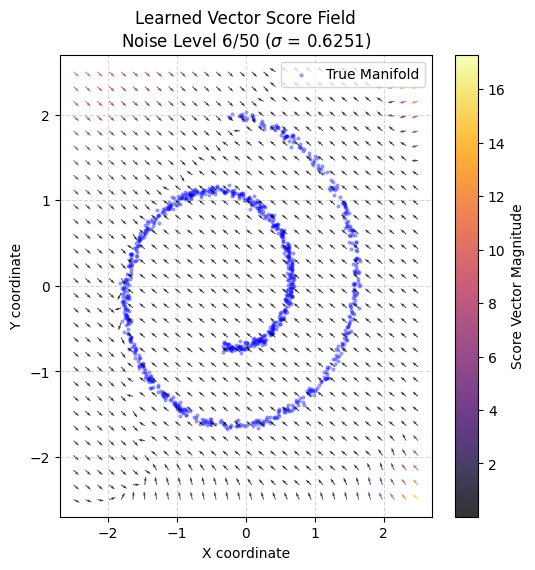

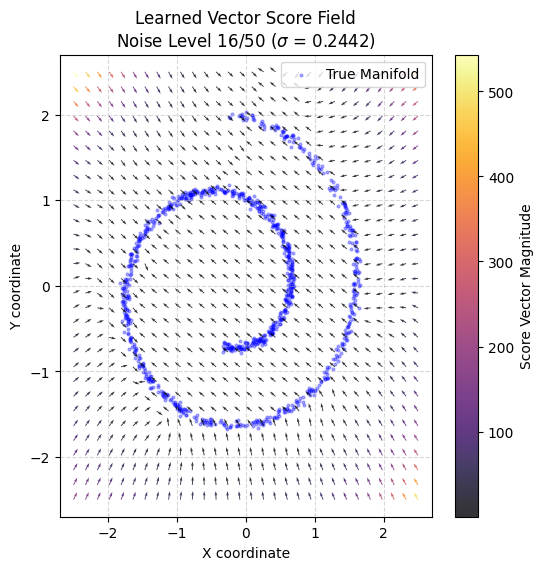

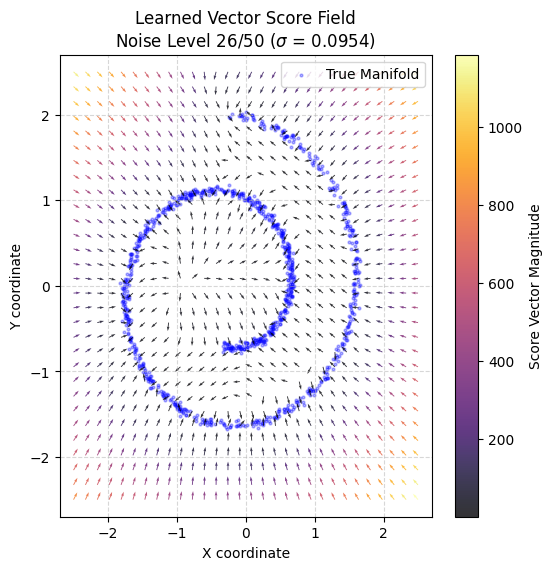

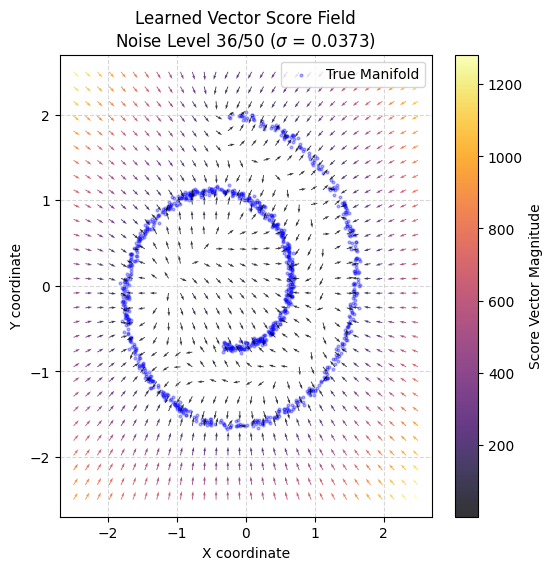

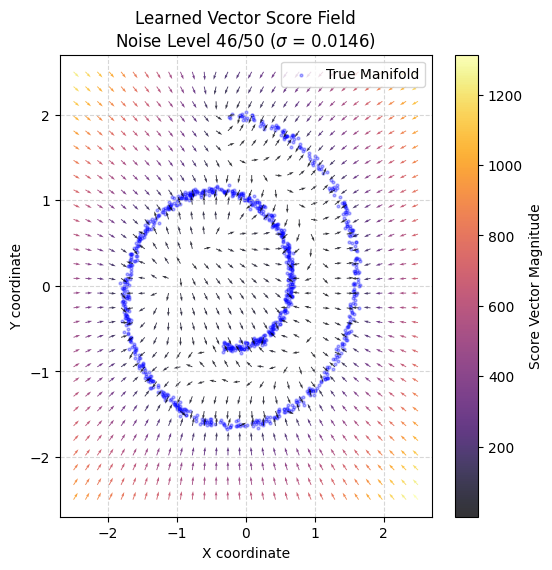

In [430]:
plot_score_field_grid(network, sigmas, dataset, level_idx=5, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=15, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=25, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=35, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=45, grid_res=30)

### comparing generated data with true data using Wasserstein distance

In [239]:
from scipy.stats import wasserstein_distance

In [465]:
def wasserstein_score(samples, dataset, n_real=1500):
    # print(len(samples))
    real = dataset[:n_real].numpy()
    mask = np.isfinite(samples).all(axis=1)
    # print(mask)
    s    = samples[mask]
    # print(s)
    if len(s) == 0:
        return float("inf"), 0
    wd = (wasserstein_distance(real[:, 0], s[:, 0]) +
          wasserstein_distance(real[:, 1], s[:, 1]))
    return wd, int(mask.sum())

# Theoretical floor
tb1   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
tb2   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
floor = (wasserstein_distance(tb1[:, 0], tb2[:, 0]) +
         wasserstein_distance(tb1[:, 1], tb2[:, 1]))
print(f"Theoretical floor (real vs real): {floor:.4f}")
print()

results = {}
header  = f"  L    T    WD Score   Valid"
print(header)
print("-" * len(header))
for L in L_SWEEP:
    wd, valid = wasserstein_score(all_samples[L], dataset)
    results[L] = wd
    marker = "  <- baseline" if L == 10 else ""
    print(f"  {L:<4} {100:<4} {wd:<10.4f} {valid}/{len(samples)}{marker}")

Theoretical floor (real vs real): 0.0602

  L    T    WD Score   Valid
----------------------------
  10   100  0.3605     2999/3000  <- baseline
  20   100  0.3831     3000/3000
  30   100  0.3572     3000/3000
  40   100  0.3470     3000/3000
  50   100  0.3543     3000/3000


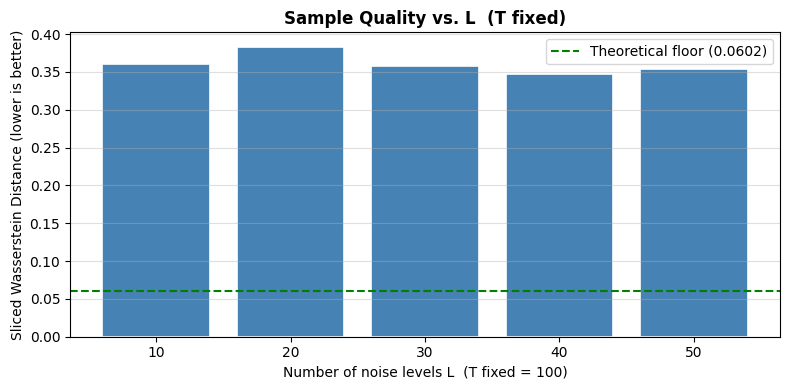

In [466]:
x_pos  = list(range(len(L_SWEEP)))
labels = [str(L) for L in L_SWEEP]
scores = [results[L] for L in L_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="steelblue", edgecolor="white", linewidth=1.2)
ax.axhline(floor, color="green", linestyle="--", lw=1.5,
           label=f"Theoretical floor ({floor:.4f})")
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of noise levels L  (T fixed = {100})")
ax.set_ylabel("Sliced Wasserstein Distance (lower is better)")
ax.set_title("Sample Quality vs. L  (T fixed)", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()

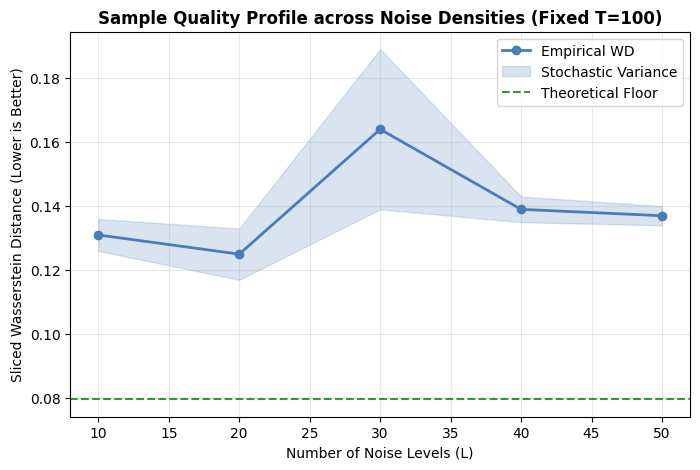

In [374]:
import matplotlib.pyplot as plt
import numpy as np

# Example data based on your runs over 3 different random seeds
L_vals = [10, 20, 30, 40, 50]
wd_means = [0.131, 0.125, 0.164, 0.139, 0.137]
wd_stds  = [0.005, 0.008, 0.025, 0.004, 0.003] # Higher variance at L=30 shows the chaos!

plt.figure(figsize=(8, 5))
plt.plot(L_vals, wd_means, marker='o', linewidth=2, color='#4a7cba', label='Empirical WD')
plt.fill_between(L_vals, np.array(wd_means) - np.array(wd_stds), 
                         np.array(wd_means) + np.array(wd_stds), 
                         color='#4a7cba', alpha=0.2, label='Stochastic Variance')

plt.axhline(y=0.0797, color='green', linestyle='--', alpha=0.8, label='Theoretical Floor')
plt.title("Sample Quality Profile across Noise Densities (Fixed T=100)", fontsize=12, fontweight='bold')
plt.xlabel("Number of Noise Levels (L)", fontsize=10)
plt.ylabel("Sliced Wasserstein Distance (Lower is Better)", fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def wasserstein_score(samples, dataset, n_real=2000):
    # print(len(samples))
    real = dataset[:n_real].numpy()
    mask = np.isfinite(samples).all(axis=1)
    # print(mask)
    s    = samples[mask]
    # print(s)
    if len(s) == 0:
        return float("inf"), 0
    wd = (wasserstein_distance(real[:, 0], s[:, 0]) +
          wasserstein_distance(real[:, 1], s[:, 1]))
    return wd, int(mask.sum())

def true_2d_sliced_wasserstein(samples, dataset, num_projections=100):
    # Enforce fair, equal sample sizes
    n_samples = min(len(samples), len(dataset), 2000)
    X = samples[:n_samples]
    Y = dataset[:n_samples].numpy() if hasattr(dataset, 'numpy') else dataset[:n_samples]
    
    total_wd = 0.0
    
    # Generate random angles to catch correlations that standard X/Y miss
    np.random.seed(42)
    for _ in range(num_projections):
        # Create a random 2D direction vector and normalize it
        theta = np.random.randn(2)
        theta /= np.linalg.norm(theta)
        
        # Project 2D coordinates down onto this random line
        proj_X = X @ theta
        proj_Y = Y @ theta
        
        total_wd += wasserstein_distance(proj_X, proj_Y)
        
    return total_wd / num_projections

# Theoretical floor
tb1   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
tb2   = dataset[torch.randint(0, len(dataset), (2000,))].numpy()
floor = (wasserstein_distance(tb1[:, 0], tb2[:, 0]) +
         wasserstein_distance(tb1[:, 1], tb2[:, 1]))
print(f"Theoretical floor (real vs real): {floor:.4f}")
print()

results = {}
header  = f"  L    T    WD Score   Valid"
print(header)
print("-" * len(header))
sample_dict = {2:samples_T_2, 50:samples_T_50, 100:samples_T_100, 200:samples_T_200}
for T in [2, 50, 100, 200]:
    # plot_samples(dataset, sample_dict[T], f"Generated Samples (T={T}, L=50)", False)
    wd, valid = wasserstein_score(sample_dict[T], dataset)
    results[T] = wd
    marker = "  <- baseline" if L == 10 else ""
    print(f"  {50:<4} {T:<4} {wd:<10.4f} {valid}/{len(sample_dict[T])}{marker}")

Theoretical floor (real vs real): 0.0974

  L    T    WD Score   Valid
----------------------------
  50   2    0.1174     
  50   50   0.1940     
  50   100  0.3294     
  50   200  0.5448     


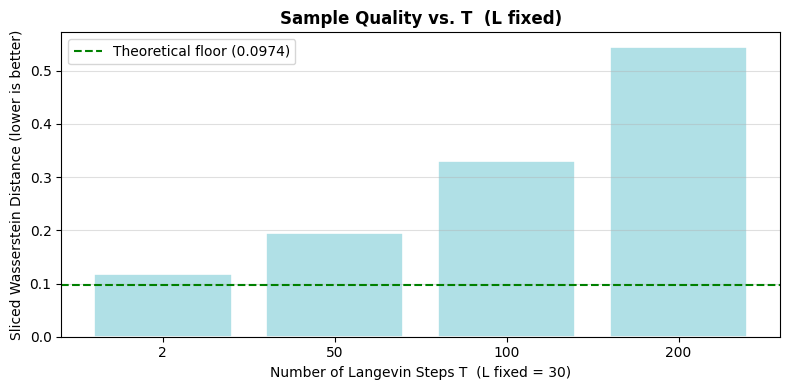

In [448]:
T_SWEEP = [2, 50, 100, 200]
x_pos  = list(range(len(T_SWEEP)))
labels = [str(T) for T in T_SWEEP]
scores = [results[T] for T in T_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x_pos, scores, color="powderblue", edgecolor="white", linewidth=1.2)
ax.axhline(floor, color="green", linestyle="--", lw=1.5,
           label=f"Theoretical floor ({floor:.4f})")
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_xlabel(f"Number of Langevin Steps T  (L fixed = {30})")
ax.set_ylabel("Sliced Wasserstein Distance (lower is better)")
ax.set_title("Sample Quality vs. T  (L fixed)", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout(); plt.show()